In [31]:
import numpy as np
#print(np.__version__)
import matplotlib.pyplot as plt
from scipy.integrate import quad
import numpy as np
import differint.differint as df

Noise model coefficient calculation. Heavy reliance on a few resources. 1. [Goulding](https://escholarship.org/content/qt15p9z9w0/qt15p9z9w0.pdf) noise notes (though there are some typos unfortunately). 2. Mengjiao provided slides on noise model. 3. [Roach IEEE](https://arxiv.org/pdf/2305.00283)

In [18]:
#nth order Gaussian shaping coefficients for noise model:
#Note t_0 is set to 1 to get the coefficients

n = 1
def R_t(x): #For I3
    return (((x/1)**n)*np.exp(n*(1-(x/1))))**2

def R_tprime(x): #For I1
    return ( (n/1**2)*( ((x/1)**(n-1))*(1-x)*np.exp(n - n*(x/1))) )**2

def R_thalf(y): #For I2, need a half derivative
    return (df.GLpoint(0.5, lambda x: (((x/1)**n)*np.exp(n*(1-(x/1)))), 0., y, 100))**2

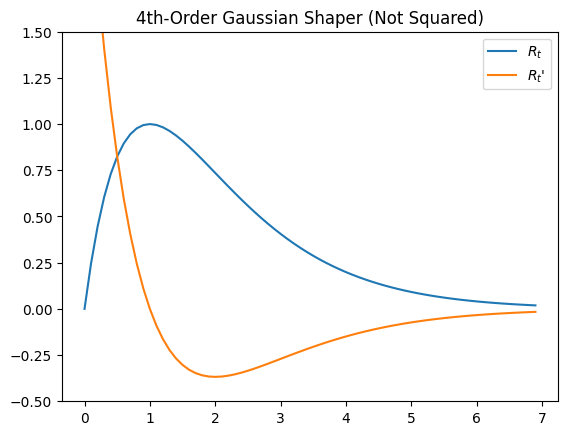

In [162]:
t = np.arange(0.0, 7.0, 0.1)

def R_t_nosq(x): #For I3
    return (((x/1)**n)*np.exp(n*(1-(x/1))))

def R_tprime_nosq(x): #For I1
    return ( (n/1**2)*( ((x/1)**(n-1))*(1-x)*np.exp(n - n*(x/1))) )

plt.title('4th-Order Gaussian Shaper (Not Squared)')
plt.ylim(-0.5,1.5)
plt.plot(t,R_t_nosq(t),label='$R_t$')
plt.plot(t,R_tprime_nosq(t),label='$R_t$\'')
plt.legend()

In [50]:
result, error = quad(R_t, 0, 100)

print(f"I3 Integral Result: {result}")
print(f"I3 Estimated Error: {error}")

result, error = quad(R_tprime, 0, 100)

print(f"I1 Integral Result: {result}")
print(f"I1 Estimated Error: {error}")

result, error = quad(R_thalf, 0, 100)

print(f"I2 Integral Result: {result}")
print(f"I2 Estimated Error: {error}")

I3 Integral Result: 1.8472640247326626
I3 Estimated Error: 1.269818692903324e-08
I1 Integral Result: 1.8472640247326635
I1 Estimated Error: 1.5797433397871097e-08
I2 Integral Result: 1.1908229751678459
I2 Estimated Error: 1.647137170407431e-08


In [320]:
#Trapezoidal shaper, starting simple right now with the triangle shaper!
#Normalize to a max amplitude of 1

tp = 2 #rise or peaking time, start by assuming the rise time and fall time are equal
td = 2 #flat top time, can set to 0 for triangle waveform


def Trap_t(x): #For I3
    if x < 0:
        return 0
    if x < tp and x > 0:
        return (x/tp)**2
    if x >= tp and x <= tp + td:
        return 1
    if x > tp+td and x < 2*tp + td:
        return (1-(1/tp)*(x-tp-td))**2
    if x >= 2*tp + td:
        return 0

def Trap_t_prime(x): #For I1
    if x < 0:
        return 0
    if x < tp and x > 0:
        return (1/tp)**2
    if x >= tp and x <= tp + td:
        return 0
    if x > tp+td and x < 2*tp + td:
        return (-1/tp)**2
    if x >= 2*tp + td:
        return 0

def Trap_t_half(y): #For I2, need a half derivative
    if x < 0:
        return 0
    if x < tp and x > 0:
        return (df.GLpoint(0.5, lambda x: x/tp, 0., y, 100))**2
    if x >= tp and x <= tp + td:
        return (df.GLpoint(0.5, lambda x: 1, 0., y, 100))**2
    if x > tp+td and x < 2*tp + td:
        return (df.GLpoint(0.5, lambda x: (1-(1/tp)*(x-tp-td)), 0., y, 100))**2
    if x >= 2*tp + td:
        return 0
        

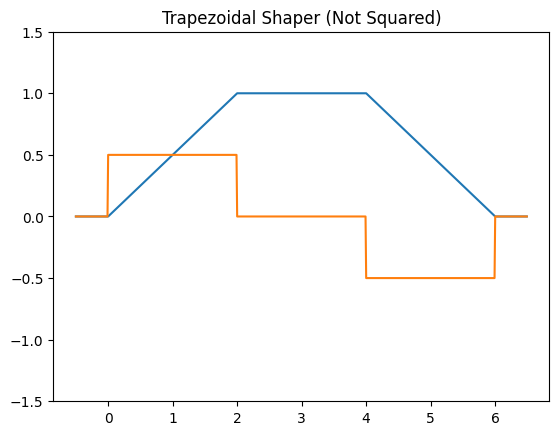

In [324]:
#This section is for plotting the actual trapezoidal waveform

dt = 0.01
t = np.arange(-0.5, 2*tp+td + 0.5, dt)

def Trap_t_nosq(x): #For I3
    if x < 0:
        return 0
    if x < tp and x > 0:
        return (1/tp)*x
    if x >= tp and x <= tp + td:
        return 1
    if x > tp+td and x < 2*tp + td:
        return 1-(1/tp)*(x-tp-td)
    if x >= 2*tp + td:
        return 0

def Trap_t_prime_nosq(x): #For I3
    if x < 0:
        return 0
    if x < tp and x > 0:
        return 1/tp
    if x >= tp and x <= tp + td:
        return 0
    if x > tp+td and x < 2*tp + td:
        return -1/tp
    if x >= 2*tp + td:
        return 0

arr = []
arr_prime = []

for x in t:
    arr.append(Trap_t_nosq(x))
    arr_prime.append(Trap_t_prime_nosq(x))

plt.title('Trapezoidal Shaper (Not Squared)')
plt.ylim(-1.5,1.5)
plt.plot(t,arr,label='$R_t$')
plt.plot(t,arr_prime,label='$R_t$\'')
#plt.legend()

In [326]:
#Noise model parameters are found here

print(f"Analytical symmetric trapezoid I3 result: {td + 2*tp/3}")
print(f"Analytical symmetric trapezoid I1 result: {2/tp}")
print(f"ESTIMATED analytical symmetric trapezoid I2 result: {0.75*np.sqrt((td + 2*tp/3)*(2/tp))} \n")

result, error = quad(Trap_t, 0, 2*tp+td)

print(f"I3 Integral Result: {result}")
#print(f"I3 Estimated Error: {error}")
result, error = quad(Trap_t_prime, 0, 2*tp+td)
print(f"I1 Integral Result: {result}")
#print(f"I1 Estimated Error: {error}")

int = 0
for x in t:
    arr_half.append(Trap_t_half_nosq(x))
    int = int + Trap_t_half_nosq(x)*dt #Yes, I do know how to integrate things manually I guess o-o;;

print(f"I2 integral result by manual integration I guess: {int}")

#Nice great! It worked! The numbers match the expected and estimated values. I understand how this shaping integration is done for these parameters.

Analytical symmetric trapezoid I3 result: 3.333333333333333
Analytical symmetric trapezoid I1 result: 1.0
ESTIMATED analytical symmetric trapezoid I2 result: 1.369306393762915 

I3 Integral Result: 3.333333333333332
I1 Integral Result: 1.0
I2 integral result by manual integration I guess: 1.3824935561697331


0


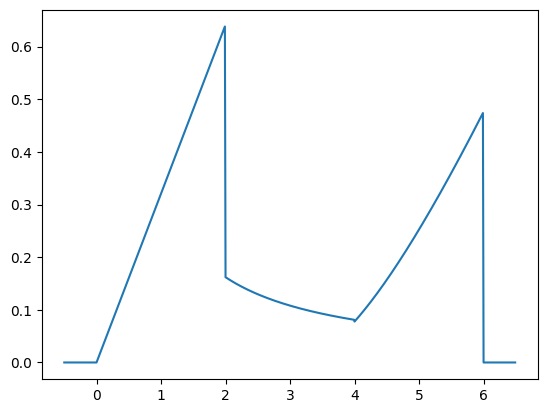

In [327]:
#This is me trying to understand half derivatives


dt = 0.01
t = np.arange(-0.5, 2*tp+td + 0.5, dt)

def Trap_t_half_nosq(y): #For I2, need a half derivative
    if x < 0:
        return 0
    if x < tp and x > 0:
        return (df.GLpoint(0.5, lambda x: x/tp, 0., y, 100))**2
    if x >= tp and x <= tp + td:
        return (df.GLpoint(0.5, lambda x: 1, 0., y, 100))**2
    if x > tp+td and x < 2*tp + td:
        return (df.GLpoint(0.5, lambda x: (1-(1/tp)*(x-tp-td)), 0., y, 100))**2
    if x >= 2*tp + td:
        return 0


arr_half = []
int = 0

for x in t:
    arr_half.append(Trap_t_half_nosq(x))
    int = int + Trap_t_half_nosq(x)*0.01 #Yes, I do know how to integrate things manually I guess o-o;;
    #print(int)
    #print(f"{x},{Trap_t_half_nosq(x)}")

#result, error = quad(Trap_t_half_nosq, 0, 1)
print(f"{Trap_t_half_nosq(0.2)}") #Why is this zero ;w; but in the for loop it's not?
#print(result)

plt.plot(t,arr_half)